# Conditional Generative Model for Images

**based on lab from MIT course ["Introduction to Flow Matching and Diffusion Models 2026"](https://diffusion.csail.mit.edu/2026/index.html)**

In [1]:
from models import VAE, DiffusionTransformerFlowModel
from trainers import VAETrainer, LatentCFGTrainer
from flow import GaussianConditionalProbabilityPath, LinearAlpha, LinearBeta
from utils.latents import visualize_latent_interpolation
from utils.fid import fid_guidance_sweep
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# Part 1. Loading datasets

In [2]:
device = torch.device("cuda:5")

cifar = datasets.CIFAR10(
    root="./data",
    train=True,
    download=True,
    transform=transforms.Compose(
        [
            transforms.RandomHorizontalFlip(),
            # Converts PIL Image to [0, 1] torch.Tensor
            transforms.ToTensor(),
            transforms.Normalize(  # Scales pixel values to [-1, 1]
                mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]
            ),
        ]
    ),
)

cifar_test = datasets.CIFAR10(
    root="./data",
    train=False,
    download=True,
    transform=transforms.Compose(
        [
            transforms.RandomHorizontalFlip(),
            # Converts PIL Image to [0, 1] torch.Tensor
            transforms.ToTensor(),
            transforms.Normalize(  # Scales pixel values to [-1, 1]
                mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]
            ),
        ]
    ),
)


def cifar_reverse_transform(x):
    x = (x + 1.0) / 2.0
    return torch.clamp(x, 0.0, 1.0)

# Part 2: Training process

## 2.1: Training a VAE

In [3]:
vae = VAE(
    data_channels=3,
    hidden_channels=[8, 16, 16],
    beta=0.01,
    reverse_transform=cifar_reverse_transform
).to(device)

In [4]:
train_dataloader = DataLoader(dataset=cifar, batch_size=64, shuffle=True)

trainer = VAETrainer(
    dataloader=train_dataloader,
)

In [5]:
# trainer.train(
#     model=vae,
#     num_epochs=100,
#     lr=1e-3,
#     warmup_steps=4 * len(train_dataloader),
#     ckpt_every=1,
#     run_name="vae_jul",
# )

In [6]:
trainer.load(model=vae, ckpt_name=f"epoch_{100}", ckpt_dir="runs/vae_jul")

Loading model with size: 0.158 MiB


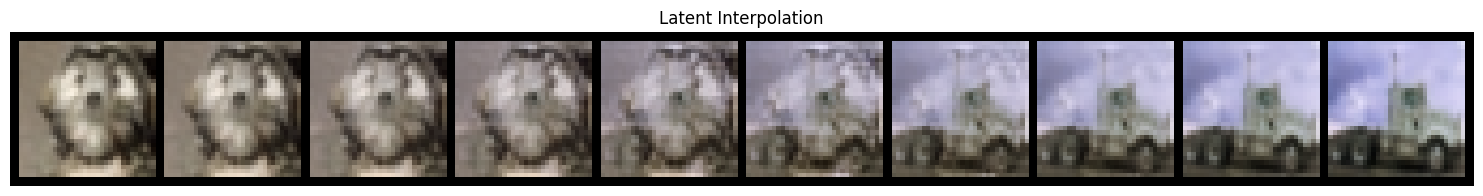

In [7]:
# Perform interpolation in the latent space
samples, _ = next(iter(DataLoader(cifar_test, batch_size=2, shuffle=True)))
samples = samples.to(device)

interpolated_samples = visualize_latent_interpolation(
    x1=samples[:1],
    x2=samples[1:2],
    vae=vae,
    n_steps=10,
    reverse_transform=cifar_reverse_transform,
)  # n_steps 3 h w

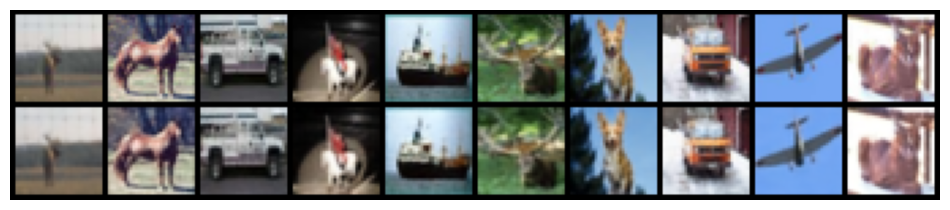

In [8]:
test_dataloader = DataLoader(dataset=cifar_test, batch_size=64, shuffle=True)
test_images, _ = next(iter(test_dataloader))
test_images = test_images[:10]
vae.visualize_samples(images=test_images);

## 2.2 Training a Latent Diffusion Model

In [9]:
latent_cifar = vae.convert_to_latent_dataset(cifar)

Converting dataset to latents: 100%|██████████| 196/196 [00:21<00:00,  9.24it/s]


In [10]:
# Initialize latent probability path
c = 16
img_size = 8

path = GaussianConditionalProbabilityPath(
    shape=[c, img_size, img_size],
    alpha=LinearAlpha(),
    beta=LinearBeta(),
)

# Initialize model
dit = DiffusionTransformerFlowModel(
    vae=vae,
    img_size=img_size,
    patch_size=1,
    num_layers=14,
    c=c,
    dim=512,
    heads=8,
    final_dim=64,
    n_classes=11,
    null_label=10,
).to(device)

# Initialize trainer
trainer = LatentCFGTrainer(
    dataloader=DataLoader(dataset=latent_cifar, batch_size=128, shuffle=True),
    path=path,
    latent_stats=vae.get_stats(),
    null_ratio=0.1,
)

In [11]:
# trainer.train(
#     model=dit,
#     num_epochs=1000,
#     lr=1e-4,
#     ckpt_every=100,
#     run_name="dit_jul",
#     warmup_steps=10000,
#     ema_decay=0.9999,
# )

In [12]:
trainer.load(dit, ckpt_name=f"epoch_{1000}", ckpt_dir="runs/dit_jul")

Loading model with size: 257.292 MiB


# Part 3: Evaluation

In [19]:
ema_dit = trainer.ema_model

In [ ]:
ema_dit.visualize_samples(
    save_path="results/gen_samples",
    samples_per_class=10,
    guidance_scales=(1.75, 2.0),
    use_tqdm=True,
);

![image](results/gen_samples.png)

In [ ]:
scores = fid_guidance_sweep(ema_dit, "samples/dit_jul_epoch_1000/", num_timesteps=250)
scores